In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
df = pd.read_csv('/content/laptopData.csv')
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   object 
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   object 
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   object 
 10  Price             1273 non-null   float64
dtypes: float64(1), object(10)
memory usage: 112.1+ KB


In [ ]:
df['Price'].describe()

,Price
count,1273.000000
mean,59955.814073
std,37332.251005
min,9270.720000
25%,31914.720000
50%,52161.120000
75%,79333.387200
max,324954.720000


In [ ]:
df.duplicated().sum()

np.int64(58)

In [ ]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()


,0
Company,1
TypeName,1
Inches,1
ScreenResolution,1
Cpu,1
Ram,1
Memory,1
Gpu,1
OpSys,1
Weight,1


In [ ]:
x = df.isnull().any(axis=1)
print(df[x])

   Company TypeName Inches ScreenResolution  Cpu  Ram Memory  Gpu OpSys  \
20     NaN      NaN    NaN              NaN  NaN  NaN    NaN  NaN   NaN   

   Weight  Price  
20    NaN    NaN  


In [ ]:
df[x]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Only 1 row has null values. Droping will not be a problem.

df = df.dropna()

print(df.isnull().sum())

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


In [ ]:
df.nunique()


,0
Company,19
TypeName,6
Inches,25
ScreenResolution,40
Cpu,118
Ram,10
Memory,40
Gpu,110
OpSys,9
Weight,189


In [ ]:
def brand(text):
    text=str(text)

    if 'Intel' in text:
        return 'Intel'

    elif 'AMD' in text:
        return 'AMD'

    else:
        return 'Samsung'


df["Cpu_Brand"]=df["Cpu"].apply(brand)
df['Cpu_Brand'].value_counts()

,count
Cpu_Brand,
Intel,1183
AMD,60
Samsung,1


In [ ]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,Intel
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...
1269,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,38378.6496,Intel
1270,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,Intel
1271,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,Intel
1272,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,Intel


In [ ]:
price = df.groupby('Company').sum(numeric_only=True)
count = sum_product = df['Company'].value_counts()

companies = pd.merge(price, count, left_index=True, right_index=True)
companies

,Price,count
Company,,
Acer,3.408850e+06,101
Apple,1.750150e+06,21
Asus,8.986270e+06,149
Chuwi,5.023718e+04,3
Dell,1.797385e+07,281
Fujitsu,7.714944e+04,2
Google,2.681582e+05,3
HP,1.505673e+07,260
Huawei,1.517414e+05,2


In [ ]:
companies['AVg_price'] = (companies['Price'] / companies['count'])
companies.reset_index(inplace=True)

companies

,Company,Price,count,AVg_price
0,Acer,3.408850e+06,101,33750.986186
1,Apple,1.750150e+06,21,83340.499886
2,Asus,8.986270e+06,149,60310.535581
3,Chuwi,5.023718e+04,3,16745.726400
4,Dell,1.797385e+07,281,63963.889520
5,Fujitsu,7.714944e+04,2,38574.720000
6,Google,2.681582e+05,3,89386.080000
7,HP,1.505673e+07,260,57910.511520
8,Huawei,1.517414e+05,2,75870.720000
9,LG,3.355042e+05,3,111834.720000


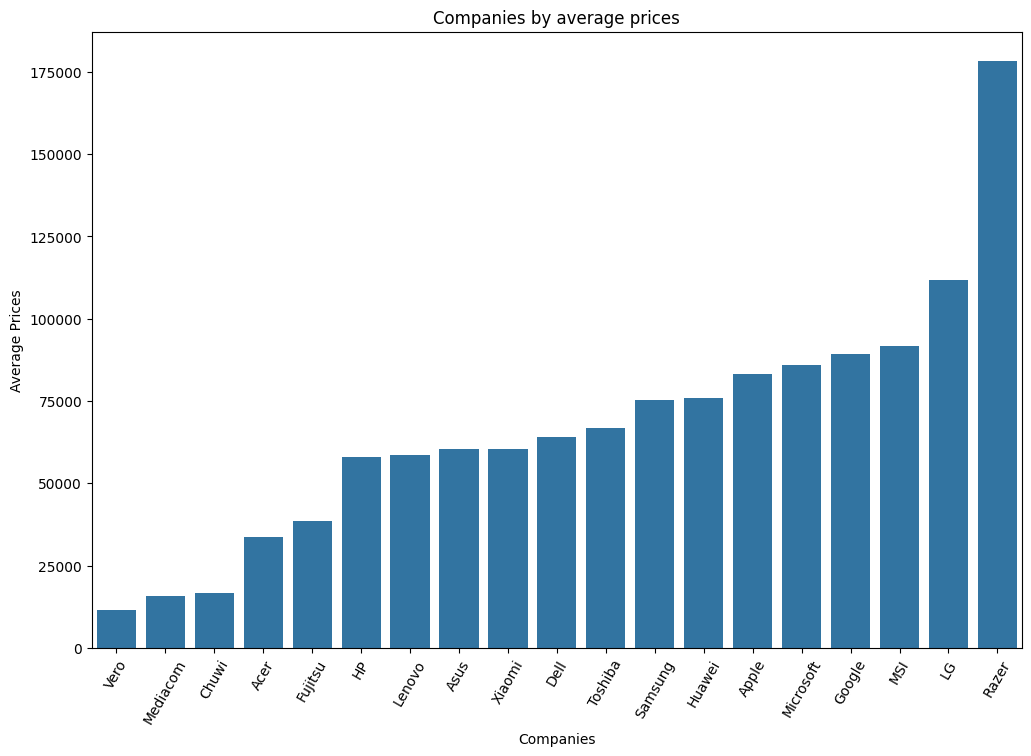

In [ ]:
plt.figure(figsize=(12,8))
sns.barplot(data=companies, x= companies['Company'], y='AVg_price', order=companies.sort_values('AVg_price', ).Company)
plt.xticks(rotation=60)
plt.title('Companies by average prices')
plt.xlabel('Companies')
plt.ylabel('Average Prices');

In [ ]:
companies_two = companies.reindex(columns=['count', 'Company','Price','AVg_price']).sort_values('count')
companies_two

,count,Company,Price,AVg_price
5,2,Fujitsu,7.714944e+04,38574.720000
8,2,Huawei,1.517414e+05,75870.720000
6,3,Google,2.681582e+05,89386.080000
3,3,Chuwi,5.023718e+04,16745.726400
9,3,LG,3.355042e+05,111834.720000
17,4,Vero,4.633762e+04,11584.404000
18,4,Xiaomi,2.415635e+05,60390.882000
13,6,Microsoft,5.154227e+05,85903.788000
12,7,Mediacom,1.100232e+05,15717.600000
14,7,Razer,1.247977e+06,178282.491429


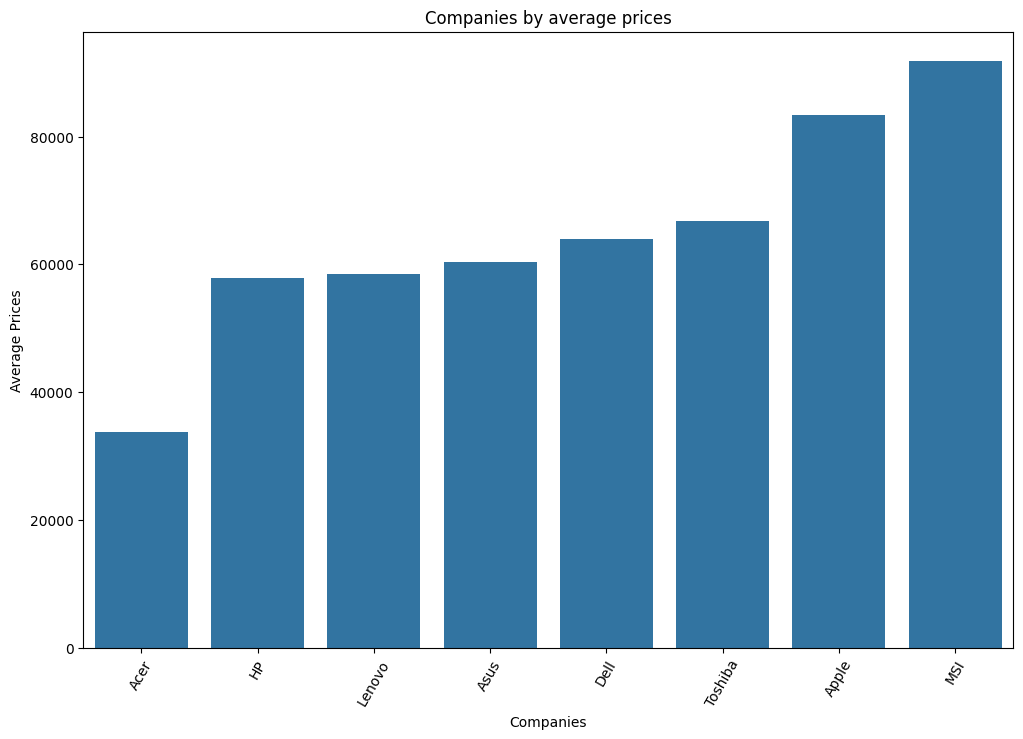

In [ ]:
#Samething, but we delete companies that have less than 10 rows.
companies_two = companies_two.reindex(columns=['count', 'Company','Price','AVg_price']).sort_values('count')
companies_two = companies_two[11:]

plt.figure(figsize=(12,8))
sns.barplot(data=companies_two, x= 'Company', y='AVg_price', order=companies_two.sort_values('AVg_price').Company)
plt.xticks(rotation=60)
plt.title('Companies by average prices')
plt.xlabel('Companies')
plt.ylabel('Average Prices');

In [ ]:
df

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_Brand
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Intel
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,Intel
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,Intel
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...
1269,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.2kg,38378.6496,Intel
1270,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,Intel
1271,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,Intel
1272,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,Intel


In [ ]:
#The most expensive and cheapest computer
print('The most expensive -->')
print(df['Price'].max())
print('-------------------------')
print('-------------------------')
print('-------------------------')
print('The cheapest -->')
print(df['Price'].min())

The most expensive -->
324954.72
-------------------------
-------------------------
-------------------------
The cheapest -->
9270.72


In [ ]:
#I will not use companies with less than 10 sample. The companies i will use are -->
companies =  ['Acer', 'HP', 'Lenovo', 'Asus', 'Dell', 'Toshiba', 'Apple', 'MSI']

need_for_compy = df.copy()

Acer = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Acer'])
HP = pd.DataFrame(need_for_compy[need_for_compy.Company == 'HP'])
Lenovo = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Lenovo'])
Asus = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Asus'])
Dell = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Dell'])
Toshiba = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Toshiba'])
Apple = pd.DataFrame(need_for_compy[need_for_compy.Company == 'Apple'])
MSI = pd.DataFrame(need_for_compy[need_for_compy.Company == 'MSI'])

Acer.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Cpu_Brand
5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.00,AMD
9,Acer,Ultrabook,14,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.60,Intel
36,Acer,Notebook,15.6,1366x768,Intel Core i3 7130U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Linux,2.1kg,19553.76,Intel
43,Acer,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,4GB,256GB SSD,Intel UHD Graphics 620,Windows 10,2.2kg,36336.96,Intel
51,Acer,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,256GB SSD,Nvidia GeForce MX150,Windows 10,2.2kg,44808.48,Intel


In [ ]:
Apple

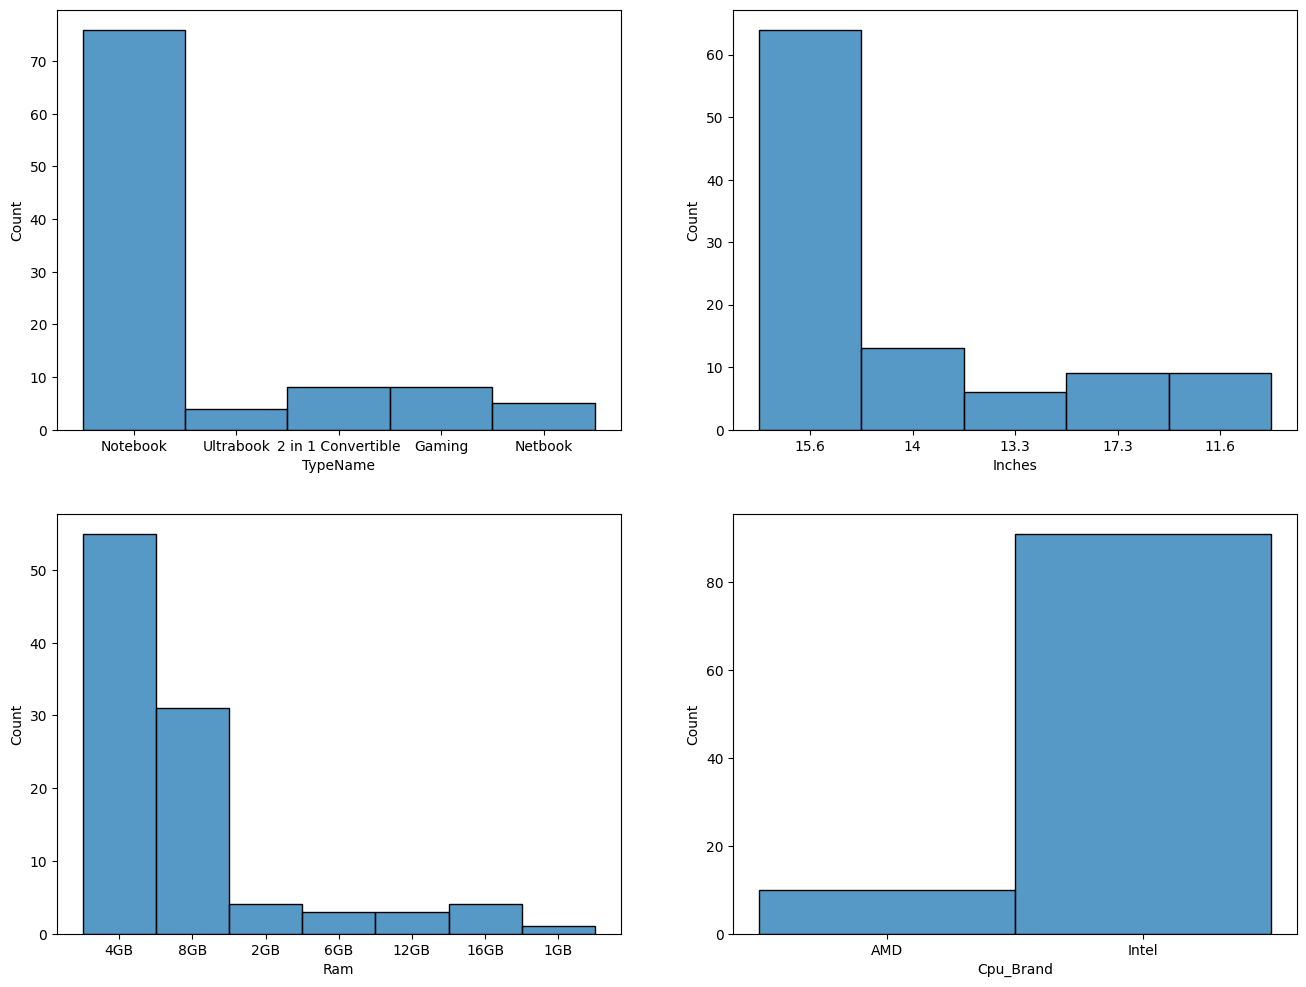

In [ ]:
def company_plots(data):

    fig, axes = plt.subplots(2,2, figsize=(16, 12))


    sns.histplot(data['TypeName'], ax=axes[0,0])

    sns.histplot(data['Inches'],  ax=axes[0, 1])

    sns.histplot(data['Ram'], ax=axes[1, 0])

    sns.histplot(data['Cpu_Brand'], ax=axes[1, 1])

    plt.show()

company_plots(Acer)